# Intent Recognition Chatbot – Data Processing & Model Training

This notebook performs the following steps:
- Text preprocessing (tokenization, language detection, lemmatization) for Persian and English
- Data augmentation using a custom Persian synonym dictionary
- Building vocabulary and tokenizing sentences
- Designing and training a Bidirectional LSTM model
- Saving the trained model and preprocessed data for later use


**Author:** _Mahdi Razaghi_

### libraries

In [2]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard,CSVLogger 
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout , Bidirectional 
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam 
from tensorflow.keras.models import Model 
from hazm  import  Lemmatizer,Normalizer
from nltk.stem import WordNetLemmatizer
from collections import  Counter
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import numpy as np
import datetime
import random
import pickle
import nltk
import json
import sys
import re


In [3]:
try:
    nltk.download('wordnet', quiet=True, raise_on_error=True)
    _has_wordnet = True
except Exception:
    _has_wordnet = False
    print("Warning: WordNet not available. Using simple fallback lemmatizer.")

class SimpleLemmatizer:
    """
    A lightweight rule-based English lemmatizer.
    Used as a fallback when WordNet is unavailable.
    """

    def __init__(self):
        # Irregular noun forms
        self.irregular_nouns = {
            "men": "man",
            "women": "woman",
            "children": "child",
            "mice": "mouse",
            "geese": "goose",
            "feet": "foot",
            "teeth": "tooth",
            "people": "person"
        }

        # Irregular verbs
        self.irregular_verbs = {
            "went": "go",
            "gone": "go",
            "done": "do",
            "did": "do",
            "seen": "see",
            "saw": "see",
            "been": "be",
            "was": "be",
            "were": "be",
            "had": "have",
            "has": "have"
        }

    def lemmatize(self, word):
        word = word.lower()

        # 1 Check irregular nouns
        if word in self.irregular_nouns:
            return self.irregular_nouns[word]

        # 2 Check irregular verbs
        if word in self.irregular_verbs:
            return self.irregular_verbs[word]

        # 3 Plural nouns rules 
        if re.search(r'ies$', word):
            return re.sub(r'ies$', 'y', word)  # cities → city

        if re.search(r'ves$', word):
            return re.sub(r'ves$', 'f', word)  # wolves → wolf

        if re.search(r'ses$|xes$|zes$|ches$|shes$', word):
            return word[:-2]  # boxes → box

        if word.endswith('s') and not word.endswith('ss'):
            return word[:-1]  # books → book

        # 4 Verb forms

        # running → run
        if re.search(r'([a-z])\1ing$', word):
            return word[:-4]

        if word.endswith('ing') and len(word) > 4:
            return word[:-3]

        # stopped → stop
        if re.search(r'([a-z])\1ed$', word):
            return word[:-3]

        if word.endswith('ed') and len(word) > 3:
            return word[:-2]

        return word

if _has_wordnet:
    lemmatizer_en = WordNetLemmatizer()
else:
    lemmatizer_en = SimpleLemmatizer()
    print("\nThe following code will use SimpleLemmatizer.")

### 1. Load and explore the dataset

In [4]:
# ============================================
# Load intents and the synonym dictionary
# ============================================

try:
    data = pd.read_json("intents.json")
    intents = data["intents"]
except FileNotFoundError:
    print("Error: 'intents.json' not found. Check the file path.")
    sys.exit(1)
except Exception as e:
    print(f"Unexpected error while loading intents.json: {e}")
    sys.exit(1)

# Load Persian synonyms for data augmentation
try:
    with open('synonym_dict.json', 'r', encoding='utf-8') as f:
        persian_synonyms = json.load(f)
except FileNotFoundError:
    print("Error: 'synonym_dict.json' not found. Check the file path.")
    sys.exit(1)

# Count patterns and contexts
total_patterns = 0
total_contexts = 0

for intent in intents:
    total_patterns += len(intent.get("patterns", []))
    total_contexts += len(intent.get("context", []))

num_tags = len(intents)

#To make the results repeatable
random.seed(42) 
np.random.seed(42)
tf.random.set_seed(42)

print(f"Total patterns: {total_patterns}")
print(f"Total contexts: {total_contexts}")
print(f"Total unique tags: {num_tags}")
print(f"Average patterns per tag: {total_patterns / num_tags:.2f}")

Total patterns: 4390
Total contexts: 1234
Total unique tags: 419
Average patterns per tag: 10.48


In [6]:
# ============================================
# Preprocessing utilities (tokenization, language detection, lemmatization)
# ============================================

def custom_word_tokenize(text):
    """
    Tokenize a Persian/English text using a regex pattern.
    Preserves words, numbers, and some punctuation.
    """
    pattern = r"""
        \w+(?:'\w+)?  
        | [^\w\s]     
        | \-           
    """
    tokens = re.findall(pattern, text, re.VERBOSE)
    return tokens


def detect_language(word: str) -> str:
    """
    Detect language of a single word.
    Returns:
        'en' for English, 'fa' for Persian/Arabic,
        'mixed' if both scripts appear, otherwise 'other'.
    """
    has_english = bool(re.search(r'[a-zA-Z]', word))
    has_persian_arabic = bool(re.search(r'[\u0600-\u06FF\uFB50-\uFDFF\uFE70-\uFEFF]', word))
    
    if has_english and not has_persian_arabic:
        return 'en'
    elif has_persian_arabic and not has_english:
        return 'fa'
    elif has_english and has_persian_arabic:
        return 'mixed'
    else:
        return 'other'


def preprocess_word(word, lemmatizer_fa, normalizer, lemmatizer_en):
    """
    Normalize, lemmatize, and clean a word based on its detected language.
    - English words are lowercased and lemmatized with NLTK's WordNet.
    - Persian words are normalized and lemmatized with Hazm.
    - Mixed or other languages are discarded (return None).
    """
    word = word.strip()
    if not word:
        return None
    
    lang = detect_language(word)
    
    if lang == 'en':
        word_lower = word.lower()
        return lemmatizer_en.lemmatize(word_lower)
    elif lang == 'fa':
        normalized = normalizer.normalize(word)
        lemmatized = lemmatizer_fa.lemmatize(normalized)
        return lemmatized.replace('#', '')
    elif lang == 'mixed':
        return None
    else:
        return None


def get_synonym(word):
    """
    Retrieve Persian synonyms from the loaded dictionary.
    Returns None if the word is not Persian or not found.
    """
    lang = detect_language(word)
    if lang != 'fa':
        return None
    return persian_synonyms.get(word, None)


def smart_augment(sentence, num_variations=2):
    """
    Perform synonym-based data augmentation on a sentence.
    - Tokenizes the sentence with custom_word_tokenize.
    - Randomly replaces one word (if a synonym exists) to create a new sentence.
    - Returns a list of unique augmented sentences (different from original).
    """
    tokens = custom_word_tokenize(sentence)
    if len(tokens) < 2:
        return []
    
    # Find candidate words that have synonyms
    ignore_chars = ['!', '?', ',', '.', '\u200c', "؟", "/", 
                    "#", "$", "^", "&", "*", "@", "%", "~"]
    candidates = []
    for idx, tok in enumerate(tokens):
        if tok in ignore_chars:
            continue
        syns = get_synonym(tok)
        if syns:
            candidates.append((idx, syns))
    
    if not candidates:
        return []
    
    new_sentences = []
    for _ in range(num_variations):
        idx, syns = random.choice(candidates)
        new_tokens = tokens.copy()
        new_tokens[idx] = random.choice(syns)
        new_sentences.append(' '.join(new_tokens))
    
    # Remove duplicates and any sentence identical to the original
    unique_new = list(set(new_sentences))
    return [s for s in unique_new if s != sentence]


In [7]:
# ============================================
# Perform augmentation on all patterns
# ============================================

augmented_patterns = []
augmented_labels = []
stats = {'original': 0, 'augmented': 0, 'no_synonym': 0}

for intent in intents:
    tag = intent["tag"]
    for pattern in intent["patterns"]:
        stats['original'] += 1
        augmented_patterns.append(pattern)
        augmented_labels.append(tag)
        
        new_versions = smart_augment(pattern, num_variations=2)
        if new_versions:
            for new_p in new_versions:
                augmented_patterns.append(new_p)
                augmented_labels.append(tag)
                stats['augmented'] += 1
        else:
            stats['no_synonym'] += 1

print(f"Augmentation completed!")
print(f"  Original sentences: {stats['original']}")
print(f"  New generated sentences: {stats['augmented']}")
print(f"  Sentences with no synonym found: {stats['no_synonym']}")
print(f"  Increase ratio: {(stats['original'] + stats['augmented']) / stats['original']:.1f}x")

Augmentation completed!
  Original sentences: 4390
  New generated sentences: 3464
  Sentences with no synonym found: 2474
  Increase ratio: 1.8x


In [8]:
# ============================================
# Save augmented dataset to JSON
# ============================================

# Build new intents list from augmented patterns and labels
new_intents = []
for intent in intents:
    tag = intent["tag"]
    patterns_for_tag = [p for j, p in enumerate(augmented_patterns) if augmented_labels[j] == tag]
    new_intents.append({
        "tag": tag,
        "patterns": patterns_for_tag,
        "context": intent["context"]
    })

with open("augmented_intents.json", "w", encoding="utf-8") as f:
    json.dump({"intents": new_intents}, f, ensure_ascii=False, indent=2)

print("Augmented dataset saved to 'augmented_intents.json'")

Augmented dataset saved to 'augmented_intents.json'


### 3. Build Vocabulary and Tokenize Sentences

In [9]:
# ============================================
# Build word to token mapping
# ============================================


lemmatizer_fa = Lemmatizer()
normalizer = Normalizer()
ignore_letters = ['!', '?', ',', '.', '\u200c', "؟", "/", 
                  "#", "$", "^", "&", "*", "@", "%", "~"]
words = []
for intent in new_intents :
    for pattern in intent["patterns"]:
        tokens = custom_word_tokenize(pattern)
        for token in tokens:
            if token in ignore_letters:
                continue
            processed = preprocess_word(token, lemmatizer_fa, normalizer, lemmatizer_en)
            if processed is not None:
                words.append(processed)
words = sorted(list(set(words)))
word_to_token = {word: i+2 for i, word in enumerate(words)}
token_to_word = {i: word for word, i in word_to_token.items()}

In [10]:
# ============================================
# Map each intent tag to a numeric id
# ============================================
tags = []
for intent in new_intents:
    tags.append(intent["tag"])
tags = sorted(list(set(tags)))
tag_to_num = {tag: i for i, tag in enumerate(tags)}
num_to_tag = {i: tag for tag, i in tag_to_num.items()}

In [11]:
# ============================================
# Convert each sentence to a sequence of token IDs
# ============================================
tokenized_sentences = []
labels = []
for intent in new_intents:
    for pattern in intent["patterns"]:
        labels.append(intent["tag"])
        tokens = custom_word_tokenize(pattern)
        token_ids = []
        for token in tokens:
            if token in ignore_letters:
                continue
            processed = preprocess_word(token, lemmatizer_fa, normalizer, lemmatizer_en)
            if processed is not None:
                token_id = word_to_token.get(processed, 1)
                token_ids.append(token_id)
        if not token_ids:
            token_ids = [1]
        tokenized_sentences.append(token_ids)
print(f"Number of tokenized sentences: {len(tokenized_sentences)}")

Number of tokenized sentences: 7854


In [12]:
# ============================================
# Determine max sentence length and pad/truncate sequences
# ============================================
max_len = max(len(sen) for sen in tokenized_sentences) if tokenized_sentences else 0
print(f"Calculated max_len: {max_len}")
padded_sentences = []
for sent in tokenized_sentences:
    if len(sent) < max_len:
        padded_sentences.append(sent + [0] * (max_len - len(sent)))
    else:
        padded_sentences.append(sent[:max_len])
train_x = np.array(padded_sentences)
train_y = np.array([tag_to_num[lab] for lab in labels])
# Shuffle
combined = list(zip(train_x, train_y))
random.shuffle(combined)
train_x, train_y = zip(*combined)
train_x = np.array(list(train_x))
train_y = np.array(list(train_y))
print(f"train_x shape: {train_x.shape}")
print(f"train_y shape: {train_y.shape}")

Calculated max_len: 12
train_x shape: (7854, 12)
train_y shape: (7854,)


### hyper parameter

In [13]:
try: #Parameters that are measured directly from the dataset itself
    VOCAB_SIZE = len(word_to_token) + 2 
    MAX_LEN = max_len
    NUM_CLASSES = len(np.unique(train_y))
    print("Hyperparameters set successfully.")
    print(f"VOCAB_SIZE: {VOCAB_SIZE}")
    print(f"MAX_LEN: {MAX_LEN}")
    print(f"NUM_CLASSES: {NUM_CLASSES}")
except NameError:
    print("Error: 'preprocessor' object not found or missing required attributes.")
    print("Please ensure the data preparation code has run and 'preprocessor' is available.")
    
    VOCAB_SIZE = 976
    MAX_LEN = 11
    NUM_CLASSES = 212
    print(f"Using placeholder values: VOCAB_SIZE={VOCAB_SIZE}, MAX_LEN={MAX_LEN}, NUM_CLASSES={NUM_CLASSES}")



MIN_SAMPLES_PER_CLASS = 2
L1_LAMBDA = 0.0   #Given the data we have, using l1 removes important features,
# so we don't use it, but we use it in the code and instead set the l1 lambda value to zero to make it ineffective.     
L2_LAMBDA = 0.0005
EMBEDDING_DIM = 128
EPOCHS = 150
LSTM_UNITS = 64
BATCH_SIZE = 64
LEARNING_RATE =  0.001
OPTIMIZER = Adam(learning_rate=LEARNING_RATE)
DROPOUT = 0.5
VALIDATION_SPLIT = 0.2

Hyperparameters set successfully.
VOCAB_SIZE: 3185
MAX_LEN: 12
NUM_CLASSES: 419


In [14]:
print("\nPreparing data for training - removing extremely rare classes...")

counter = Counter(train_y)

valid_classes = [c for c, cnt in counter.items() if cnt >= MIN_SAMPLES_PER_CLASS]

mask_valid = np.isin(train_y, valid_classes)
train_x_filtered = train_x[mask_valid]
train_y_filtered = train_y[mask_valid]

print(f"After removing classes with < {MIN_SAMPLES_PER_CLASS} samples:")
print(f"  - Samples: {len(train_y_filtered)} (was {len(train_y)})")
print(f"  - Classes: {len(set(train_y_filtered))} (was {len(set(train_y))})")


X_train, X_val, y_train, y_val = train_test_split(
    train_x_filtered, train_y_filtered,
    test_size=VALIDATION_SPLIT, 
    random_state=42,
    stratify=train_y_filtered
)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

print("Weights per class (first 10):", list(class_weight_dict.items())[:10])

print(f"Total patterns after augmentation: {len(train_x)}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"Average patterns per class: {len(train_x) / NUM_CLASSES:.2f}")


Preparing data for training - removing extremely rare classes...
After removing classes with < 2 samples:
  - Samples: 7854 (was 7854)
  - Classes: 419 (was 419)
Weights per class (first 10): [(0, 1.0710876235935902), (1, 0.7497613365155131), (2, 0.5170767838038022), (3, 0.49984089101034207), (4, 0.7497613365155131), (5, 2.1421752471871804), (6, 2.4992044550517103), (7, 2.4992044550517103), (8, 2.1421752471871804), (9, 2.4992044550517103)]
Total patterns after augmentation: 7854
Number of classes: 419
Vocabulary size: 3185
Average patterns per class: 18.74


In [15]:
preprocessed_data = {
    'word_to_token': word_to_token,
    'token_to_word': token_to_word,
    'train_x': X_train,          # numpy array
    'train_y': y_train,          # numpy array
    'tags': tags,
    'tag_to_num': tag_to_num,
    'num_to_tag': num_to_tag,
    'max_len': max_len,
    'vocab_size': len(word_to_token) + 2,
    'num_classes': len(tags)
}

with open('preprocessed_data.pkl', 'wb') as f:
    pickle.dump(preprocessed_data, f)

print("Data saved to preprocessed_data.pkl")

Data saved to preprocessed_data.pkl


# creat model :


In [16]:
def build_advanced_model(vocab_size, embedding_dim, input_length, lstm_units, num_classes, dropout_rate=0.5):

    inputs = Input(shape=(input_length,))

    x = Embedding(vocab_size, embedding_dim, mask_zero=True)(inputs)

    x = Bidirectional(LSTM(lstm_units, dropout=dropout_rate, recurrent_dropout=0.1))(x)

    x = Dropout(dropout_rate)(x)

    x = Dense(128, activation='relu')(x)

    x = Dropout(dropout_rate)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs)

model = build_advanced_model(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    input_length=MAX_LEN,
    lstm_units=LSTM_UNITS,
    num_classes=NUM_CLASSES,
    dropout_rate=DROPOUT
)

model.compile(optimizer=OPTIMIZER,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Model Architecture:")
model.summary()


Model Architecture:
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 12)]              0         
                                                                 
 embedding (Embedding)       (None, 12, 128)           407680    
                                                                 
 bidirectional (Bidirection  (None, 128)               98816     
 al)                                                             
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 128)               16512     
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                        

In [17]:
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
model_checkpoint_path = "best_model.keras"
final_model_path = "tajan_model.keras"

def get_training_callbacks():

    tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

    csv_logger = CSVLogger('training_log.csv', append=True)

    model_checkpoint_callback = ModelCheckpoint(
        filepath=model_checkpoint_path,
        save_best_only=True,
        monitor='val_accuracy', 
        mode='max',             
        verbose=2
    )

    early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=12,           
    mode='min',
    restore_best_weights=True,
    verbose=2
    )

    reduce_lr_callback = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=6,            
    min_lr=1e-6,
    verbose=1
    )

    return [tensorboard_callback, model_checkpoint_callback, early_stopping_callback, reduce_lr_callback,csv_logger]

callbacks = get_training_callbacks()
print("Callbacks configured.")

Callbacks configured.


### 4. Model Training

In [18]:
print("\nStarting model training...")


if 'X_train' in locals() and X_train.size > 0 and y_train.size > 0:
    history = model.fit(
        X_train,
        y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_val,y_val),
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=1 
    )
    print("\nModel training finished.")
    print("\nEvaluating the best model found during training...")
    model.save(final_model_path)
else:
    print("\nSkipping training and evaluation due to missing or empty training data.")



Starting model training...
Epoch 1/150


97/99 [============================>.] - ETA: 0s - loss: 6.0428 - accuracy: 0.0037
Epoch 1: val_accuracy improved from -inf to 0.02355, saving model to best_model.keras
99/99 [==============================] - 13s 52ms/step - loss: 6.0392 - accuracy: 0.0038 - val_loss: 6.0285 - val_accuracy: 0.0236 - lr: 0.0010
Epoch 2/150
98/99 [============================>.] - ETA: 0s - loss: 6.0198 - accuracy: 0.0100
Epoch 2: val_accuracy did not improve from 0.02355
99/99 [==============================] - 4s 43ms/step - loss: 6.0192 - accuracy: 0.0102 - val_loss: 5.9214 - val_accuracy: 0.0185 - lr: 0.0010
Epoch 3/150
99/99 [==============================] - ETA: 0s - loss: 5.8238 - accuracy: 0.0185
Epoch 3: val_accuracy improved from 0.02355 to 0.06238, saving model to best_model.keras
99/99 [==============================] - 4s 44ms/step - loss: 5.8238 - accuracy: 0.0185 - val_loss: 5.3712 - val_accuracy: 0.0624 - lr: 0.0010
Epoch 4/150
98/99 [==========

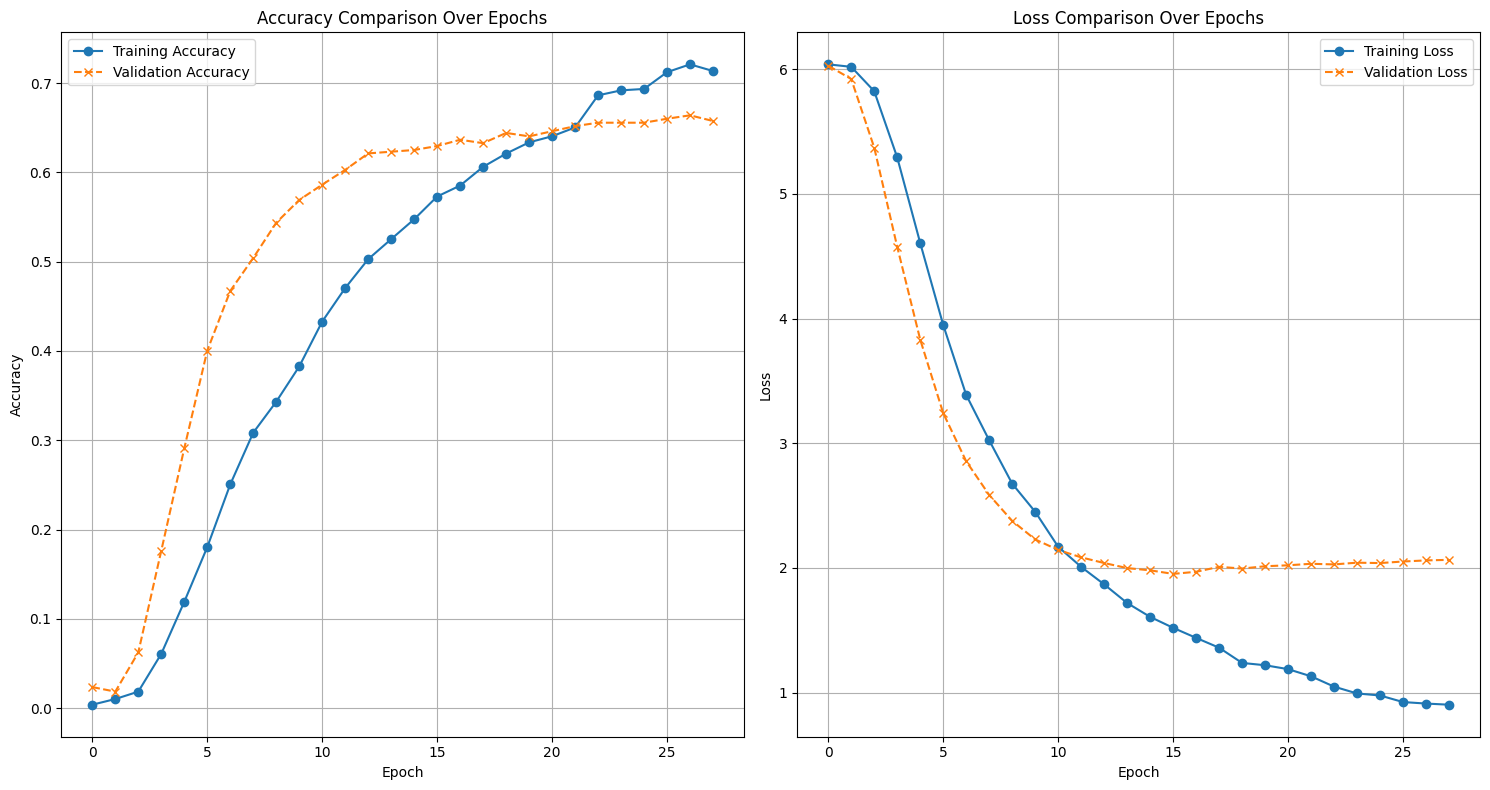

In [ ]:
# ============================================
# Plot training history (filter only last run)
# ============================================

csv_file_path = 'training_log.csv'

try:
    df = pd.read_csv(csv_file_path)
    
   
    if len(df) > 1:

        reset_indices = df[df['epoch'].diff() < 0].index.tolist()
        if reset_indices:

            last_start = reset_indices[-1]
            df = df.iloc[last_start:].reset_index(drop=True)
            df['epoch'] = range(len(df))  #
    
    plt.figure(figsize=(15, 8))

    plt.subplot(1, 2, 1)
    plt.plot(df['epoch'], df['accuracy'], marker='o', linestyle='-', label='Training Accuracy')
    plt.plot(df['epoch'], df['val_accuracy'], marker='x', linestyle='--', label='Validation Accuracy')
    plt.title('Accuracy Comparison Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(df['epoch'], df['loss'], marker='o', linestyle='-', label='Training Loss')
    plt.plot(df['epoch'], df['val_loss'], marker='x', linestyle='--', label='Validation Loss')
    plt.title('Loss Comparison Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
